# 📘 Machine Learning Masterclass
## Module 6 — Dimensionality Reduction & Anomaly Detection

**Datasets used**
| Section | Dataset |
|---------|---------|
| Dimensionality Reduction | `Iris.csv` (150 samples × 4 features + species label) |
| Anomaly Detection | `embedded_system_network_security_dataset.csv` (1 000 network packets, 90 % normal / 10 % anomalous) |

**Learning outcomes**  
By the end of this notebook you will be able to:
- Explain *why* reducing dimensions is necessary and choose the right technique for each task
- Apply PCA, t-SNE, and UMAP to real data and interpret every plot
- Understand the mechanics of Isolation Forest, One-Class SVM, LOF, and Autoencoders
- Build a complete anomaly-detection pipeline on network-traffic data

---


## 0 · Environment Setup
We begin by importing every library needed in this notebook and loading both datasets.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
print("✅  All libraries loaded successfully.")

✅  All libraries loaded successfully.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Data path
data_path = '/content/drive/MyDrive/Dr_Wale Accelerator Programme/Week 5/Day 3/Iris.csv'

# ── Load Iris (Dimensionality Reduction) ─────────────────────────────────────
iris_raw = pd.read_csv(data_path)
iris_raw.drop(columns=['Id'], inplace=True)          # drop row-id column
X_iris   = iris_raw.drop(columns=['Species']).values  # shape (150, 4)
y_iris   = iris_raw['Species'].values
labels_iris = np.unique(y_iris)

print("Iris dataset")
print(f"  Shape : {iris_raw.shape}")
print(f"  Features : {list(iris_raw.columns[:-1])}")
print(f"  Classes  : {list(labels_iris)}")
iris_raw.head()

Iris dataset
  Shape : (150, 5)
  Features : ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
  Classes  : ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# Data path
data_path1 = '/content/drive/MyDrive/Dr_Wale Accelerator Programme/Week 5/Day 3/embedded_system_network_security_dataset.csv'

# ── Load Network Security (Anomaly Detection) ─────────────────────────────────
sec_raw = pd.read_csv(data_path1)
# Convert bool columns to int so sklearn is happy
bool_cols = sec_raw.select_dtypes(bool).columns.tolist()
sec_raw[bool_cols] = sec_raw[bool_cols].astype(int)

y_sec   = sec_raw['label'].astype(int).values          # 0 = normal, 1 = anomaly
X_sec   = sec_raw.drop(columns=['label']).values

print("Network Security dataset")
print(f"  Shape   : {sec_raw.shape}")
print(f"  Normal  : {(y_sec==0).sum()}  |  Anomaly : {(y_sec==1).sum()}")
print(f"  Features: {list(sec_raw.drop(columns=['label']).columns)}")
sec_raw.head()

Network Security dataset
  Shape   : (1000, 18)
  Normal  : 900  |  Anomaly : 100
  Features: ['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy', 'protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']


,packet_size,inter_arrival_time,src_port,dst_port,packet_count_5s,mean_packet_size,spectral_entropy,frequency_band_energy,label,protocol_type_TCP,protocol_type_UDP,src_ip_192.168.1.2,src_ip_192.168.1.3,dst_ip_192.168.1.5,dst_ip_192.168.1.6,tcp_flags_FIN,tcp_flags_SYN,tcp_flags_SYN-ACK
0,0.405154,0.620362,62569,443,0.857143,0.0,0.834066,0.534891,0.0,0,1,1,0,0,0,0,0,0
1,0.527559,0.741288,59382,443,0.785714,0.0,0.147196,0.990757,0.0,0,1,0,0,0,1,0,1,0
2,0.226199,0.485116,65484,80,0.285714,0.0,0.855192,0.031781,0.0,0,1,0,0,1,0,0,0,0
3,0.573372,0.450965,51707,53,0.142857,0.0,0.153220,0.169958,0.0,0,0,0,1,0,0,0,0,0
4,0.651396,0.888740,26915,53,0.714286,0.0,0.923916,0.552053,0.0,1,0,0,1,0,0,0,1,0


---
# Part A — Dimensionality Reduction

---

## A1 · Why Dimensionality Reduction Matters

Real-world datasets routinely contain tens, hundreds, or thousands of features.
Working in such high-dimensional spaces creates three intertwined problems:

### The Curse of Dimensionality
As the number of dimensions $d$ grows, the **volume of the space grows exponentially**.
To keep the same statistical density you must exponentially more data — data you almost
never have. A practical consequence: distance metrics become less meaningful because
every point is roughly the same distance from every other point.

### Visualisation wall
Humans can perceive at most 3 spatial dimensions. Without reduction we cannot plot
our data and therefore cannot *see* what the model is learning.

### Computational cost
Many algorithms scale as $O(n \cdot d^2)$ or worse. Cutting $d$ from 100 to 2 can
deliver a 2 500× speed-up.

### Two philosophies
| Approach | What it does | Examples |
|---|---|---|
| **Feature Selection** | Picks a *subset* of original features, discarding the rest | Correlation filter, Lasso, RFE |
| **Feature Extraction** | *Creates new* features as mathematical combinations of the originals | PCA, t-SNE, UMAP, Autoencoders |

Feature selection preserves interpretability (the surviving features still have their
original meaning). Feature extraction can capture far more variance in fewer dimensions,
but the new axes are abstract combinations.

> **Rule of thumb:** use feature selection when you need to explain predictions to a
> business stakeholder; use feature extraction when predictive power matters most.


---
## A2 · Principal Component Analysis (PCA)

### Theory

PCA is a **linear** dimensionality-reduction technique. Its goal is to find the
directions in feature space along which the data varies the most, then project the
data onto those directions.

**Step-by-step mechanics**

1. **Centre the data** — subtract the column mean so every feature has zero mean.
2. **Compute the covariance matrix** $\Sigma = \frac{1}{n-1} X^T X$ (where $X$ is
   already centred). $\Sigma$ is symmetric $d \times d$ and captures how every pair
   of features co-varies.
3. **Eigen-decomposition** — find the eigenvectors $\mathbf{v}_1, \mathbf{v}_2, \ldots$
   and their associated eigenvalues $\lambda_1 \geq \lambda_2 \geq \ldots$ of $\Sigma$.
   - Each **eigenvector** is a direction in feature space (a *principal component axis*).
   - The corresponding **eigenvalue** tells you how much variance lies along that axis.
4. **Select** the top $k$ eigenvectors (those with the largest eigenvalues).
5. **Project** — multiply $X$ by the matrix formed from those $k$ eigenvectors to get
   the reduced representation $Z = X V_k$.

**Why eigenvectors?**  
The covariance matrix is symmetric positive semi-definite, so its eigenvectors are
orthogonal. This means each principal component captures a *unique, non-overlapping*
portion of the variance. No information is double-counted.

**Explained variance ratio**

$$\text{EVR}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

If EVR of the first two PCs is 0.95, projecting to 2D retains 95 % of all variation.

### Assumptions & limitations
- PCA is *linear* — it cannot capture curved manifolds (t-SNE and UMAP can).
- Scale-sensitive: always **standardise** features first (zero mean, unit variance).
- PCA preserves *global* structure; local neighbourhood relationships may be distorted.


=== Manual PCA on Iris ===

Covariance matrix (4×4):
[[ 1.007 -0.11   0.878  0.823]
 [-0.11   1.007 -0.423 -0.359]
 [ 0.878 -0.423  1.007  0.969]
 [ 0.823 -0.359  0.969  1.007]]

Eigenvalues  : [2.9304 0.9274 0.1483 0.0207]
Explained var: [0.7277 0.2303 0.0368 0.0052]
Cumulative   : [0.7277 0.958  0.9948 1.    ]


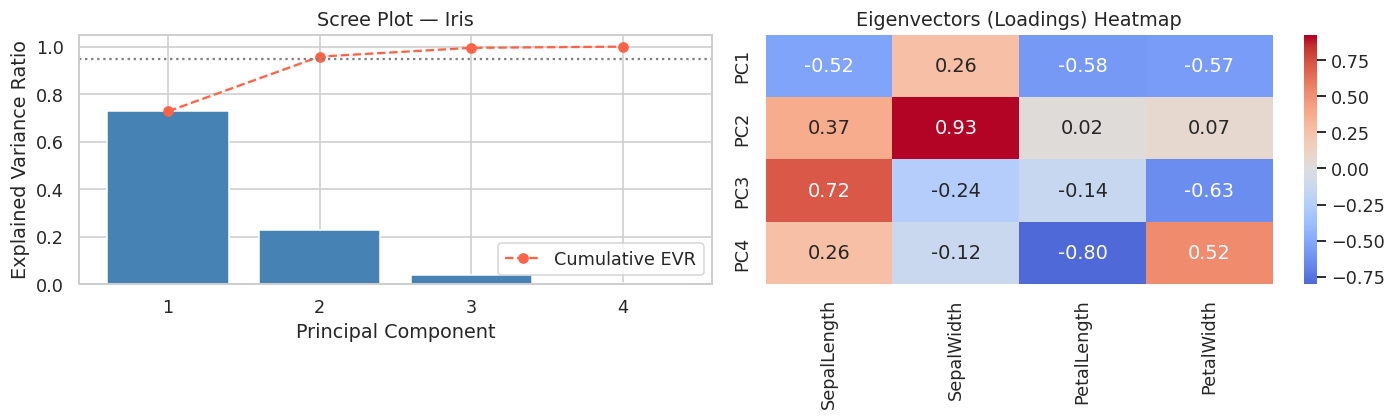


Interpretation: PC1 captures mostly petal features (large positive loadings)
PC2 is dominated by sepal width (contrasts with other features)


In [5]:
# ── Step 0: Standardise the Iris features ────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# ── Step 1: Manual covariance & eigen-decomposition (educational) ─────────────
cov_matrix  = np.cov(X_scaled.T)                 # 4×4 covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# eigh returns ascending order → reverse
eigenvalues  = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

explained_ratio = eigenvalues / eigenvalues.sum()

print("=== Manual PCA on Iris ===")
print(f"\nCovariance matrix (4×4):\n{np.round(cov_matrix,3)}")
print(f"\nEigenvalues  : {np.round(eigenvalues,4)}")
print(f"Explained var: {np.round(explained_ratio,4)}")
print(f"Cumulative   : {np.round(np.cumsum(explained_ratio),4)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, 5), explained_ratio, color='steelblue', edgecolor='white')
axes[0].plot(range(1, 5), np.cumsum(explained_ratio), 'o--', color='tomato',
             label='Cumulative EVR')
axes[0].axhline(0.95, linestyle=':', color='grey')
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance Ratio',
            title='Scree Plot — Iris', xticks=range(1, 5))
axes[0].legend()

# Eigenvector heatmap
feat_names = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
sns.heatmap(eigenvectors[:, :4].T, annot=True, fmt='.2f',
            xticklabels=feat_names, yticklabels=[f'PC{i+1}' for i in range(4)],
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Eigenvectors (Loadings) Heatmap')
plt.tight_layout(); plt.show()
print("\nInterpretation: PC1 captures mostly petal features (large positive loadings)")
print("PC2 is dominated by sepal width (contrasts with other features)")

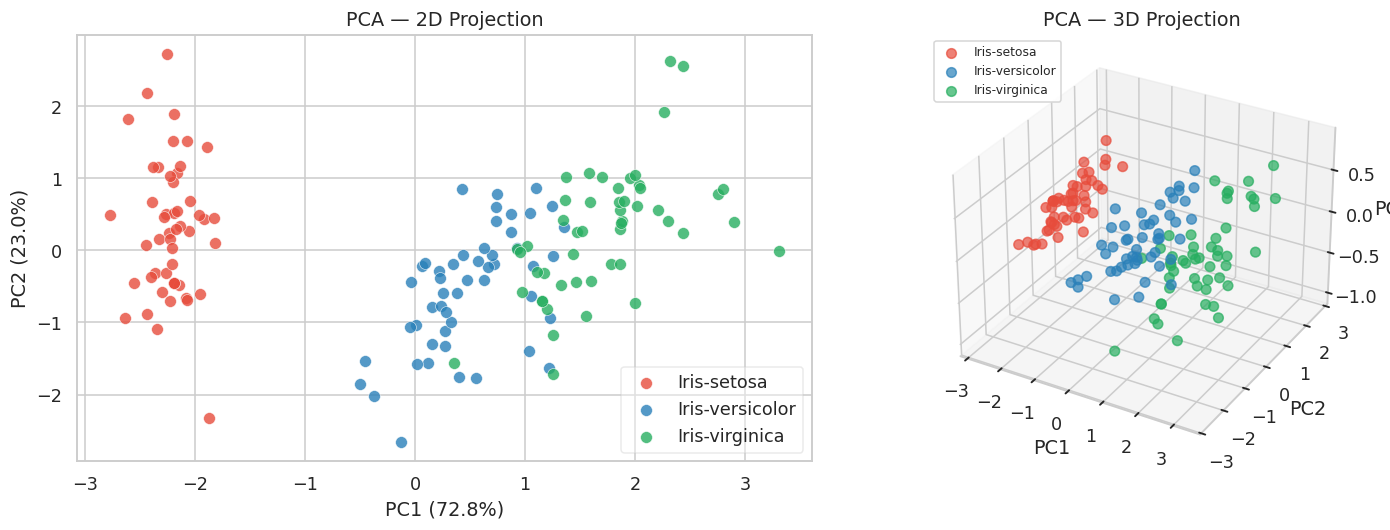

2 PCs retain 95.8% of variance
3 PCs retain 99.5% of variance

Key observation: Setosa is perfectly linearly separable from the others.
Versicolor and Virginica show mild overlap — they differ mainly on PC2.


In [6]:
# ── sklearn PCA — 2D and 3D projections ────────────────────────────────────
pca2 = PCA(n_components=2, random_state=42)
pca3 = PCA(n_components=3, random_state=42)

Z2 = pca2.fit_transform(X_scaled)
Z3 = pca3.fit_transform(X_scaled)

colors = {'Iris-setosa': '#e74c3c', 'Iris-versicolor': '#2980b9', 'Iris-virginica': '#27ae60'}

fig = plt.figure(figsize=(14, 5))

# ── 2D ──
ax1 = fig.add_subplot(121)
for sp in labels_iris:
    mask = y_iris == sp
    ax1.scatter(Z2[mask, 0], Z2[mask, 1], label=sp, alpha=0.8,
                color=colors[sp], edgecolors='white', linewidths=0.4, s=60)
ax1.set(xlabel=f'PC1 ({pca2.explained_variance_ratio_[0]:.1%})',
        ylabel=f'PC2 ({pca2.explained_variance_ratio_[1]:.1%})',
        title='PCA — 2D Projection')
ax1.legend(framealpha=0.4)

# ── 3D ──
ax2 = fig.add_subplot(122, projection='3d')
for sp in labels_iris:
    mask = y_iris == sp
    ax2.scatter(Z3[mask,0], Z3[mask,1], Z3[mask,2],
                label=sp, color=colors[sp], alpha=0.7, s=40)
ax2.set(xlabel=f'PC1', ylabel='PC2', zlabel='PC3', title='PCA — 3D Projection')
ax2.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

total_2d = pca2.explained_variance_ratio_.sum()
total_3d = pca3.explained_variance_ratio_.sum()
print(f"2 PCs retain {total_2d:.1%} of variance")
print(f"3 PCs retain {total_3d:.1%} of variance")
print("\nKey observation: Setosa is perfectly linearly separable from the others.")
print("Versicolor and Virginica show mild overlap — they differ mainly on PC2.")

---
## A3 · t-SNE: Preserving Local Structure

### What problem does t-SNE solve?
PCA is linear. If the true data manifold is curved (like a Swiss roll), PCA flattens it
destructively. **t-SNE (t-distributed Stochastic Neighbour Embedding)** is a nonlinear
technique that *prioritises keeping nearby points nearby* in the low-dimensional embedding.

### How it works — conceptually
1. In the **original high-dimensional space**, t-SNE computes a probability $p_{ij}$
   for every pair of points: how likely is point $j$ to be a *neighbour* of point $i$?
   This is modelled with a Gaussian kernel; the width is controlled by `perplexity`.
2. In the **low-dimensional embedding**, it computes analogous probabilities $q_{ij}$
   using a **Student's t-distribution** (heavy tails). The t-distribution prevents the
   "crowding problem" where many high-dimensional points would collapse into a tiny
   region.
3. It minimises the **KL divergence** between $P$ and $Q$ using gradient descent,
   iteratively moving points so that $q_{ij} \approx p_{ij}$.

### Key parameters
| Parameter | Effect |
|---|---|
| `perplexity` (5–50) | Effective number of neighbours. Low → local focus, high → broader structure. Typical: 30. |
| `n_iter` | Number of gradient-descent steps. Use ≥ 1 000. |
| `learning_rate` | Step size. `'auto'` works well in sklearn ≥ 1.2. |

### Critical limitations
- **Non-deterministic** — different runs can produce different-looking plots (use `random_state`).
- **Distances between clusters are NOT meaningful** — two far-apart clusters in t-SNE
  may be closer in reality than two nearby ones. Never conclude "clusters A and B are
  similar because they are close in the t-SNE plot."
- **Cluster sizes are not meaningful** — t-SNE can exaggerate or shrink cluster volume.
- **Slow on large datasets** — $O(n^2)$ naive, $O(n \log n)$ with Barnes-Hut approximation.
- Always run PCA first (to ~50 dims) when $d$ is large, then apply t-SNE.

### When to use t-SNE
t-SNE excels at **revealing cluster structure** in data exploration. It is not suitable
for pre-processing before a classifier (the embedding is not defined for new points).


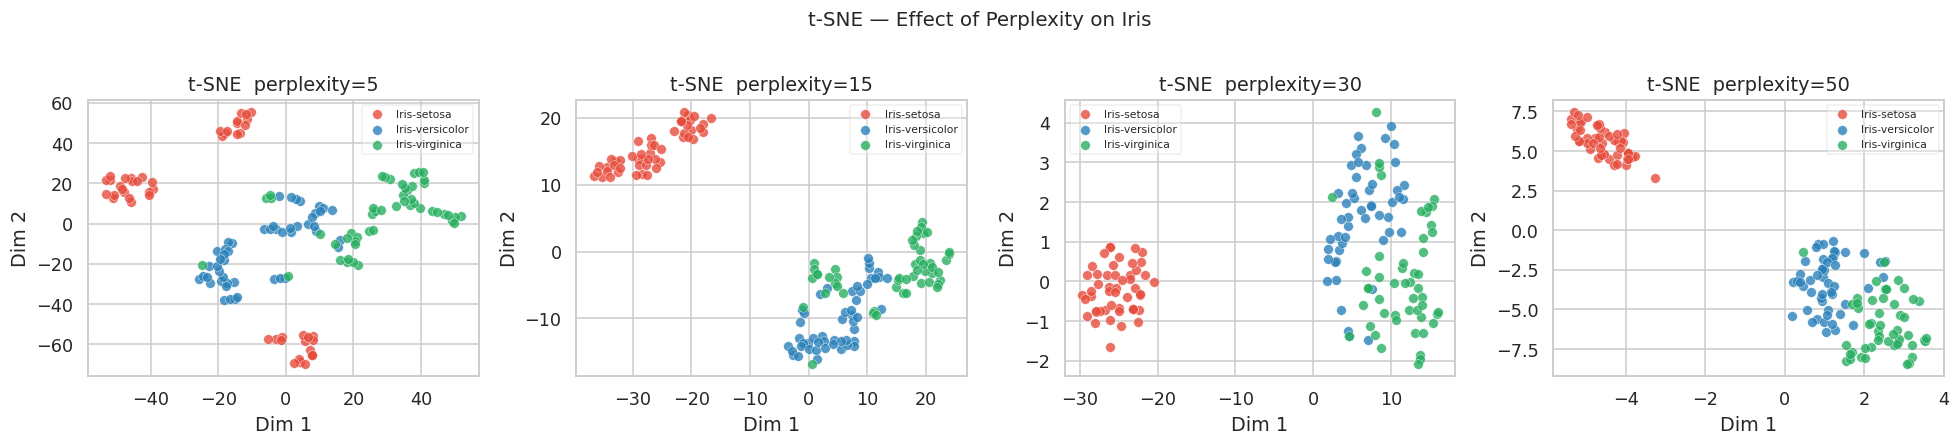

Note: perplexity=30 gives the clearest cluster structure for this dataset.
Very low perplexity (5) creates fragmented micro-clusters.
Very high perplexity (50) begins to lose local detail.


In [7]:
# ── t-SNE on Iris — effect of perplexity ─────────────────────────────────────
perplexities = [5, 15, 30, 50]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, perp in zip(axes, perplexities):
    tsne  = TSNE(n_components=2, perplexity=perp, n_iter=1000,
                 learning_rate='auto', init='pca', random_state=42)
    Z_tsne = tsne.fit_transform(X_scaled)
    for sp in labels_iris:
        mask = y_iris == sp
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                   label=sp, alpha=0.8, s=40, color=colors[sp],
                   edgecolors='white', linewidths=0.3)
    ax.set(title=f't-SNE  perplexity={perp}', xlabel='Dim 1', ylabel='Dim 2')
    ax.legend(fontsize=7, framealpha=0.3)

plt.suptitle('t-SNE — Effect of Perplexity on Iris', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
print("Note: perplexity=30 gives the clearest cluster structure for this dataset.")
print("Very low perplexity (5) creates fragmented micro-clusters.")
print("Very high perplexity (50) begins to lose local detail.")

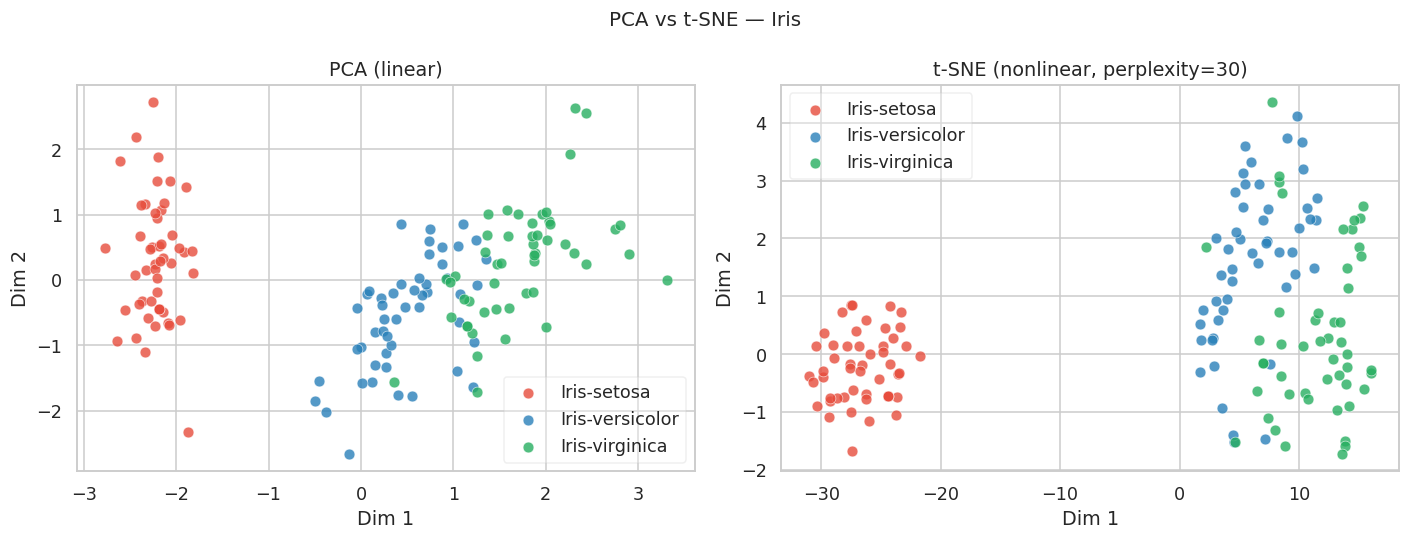

Both methods cleanly separate Setosa.
t-SNE produces tighter, more compact clusters for Versicolor & Virginica,
but remember: the inter-cluster distances in t-SNE carry no geometric meaning.


In [9]:
# ── Best t-SNE embedding: PCA init, perplexity=30 ────────────────────────────
tsne_best = TSNE(n_components=2, perplexity=30, n_iter=2000,
                 learning_rate='auto', init='pca', random_state=42)
Z_tsne = tsne_best.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Side-by-side PCA vs t-SNE
for ax, Z, title in zip(axes,
                         [Z2, Z_tsne],
                         ['PCA (linear)', 't-SNE (nonlinear, perplexity=30)']):
    for sp in labels_iris:
        mask = y_iris == sp
        ax.scatter(Z[mask, 0], Z[mask, 1], label=sp, alpha=0.8, s=50,
                   color=colors[sp], edgecolors='white', linewidths=0.4)
    ax.set(title=title, xlabel='Dim 1', ylabel='Dim 2')
    ax.legend(framealpha=0.3)

plt.suptitle('PCA vs t-SNE — Iris', fontsize=13)
plt.tight_layout(); plt.show()
print("Both methods cleanly separate Setosa.")
print("t-SNE produces tighter, more compact clusters for Versicolor & Virginica,")
print("but remember: the inter-cluster distances in t-SNE carry no geometric meaning.")

---
## A4 · UMAP — Modern Alternative to t-SNE

### Intuition
**UMAP (Uniform Manifold Approximation and Projection)** was introduced by McInnes et al.
in 2018. Like t-SNE it is a nonlinear manifold-learning method, but it rests on firmer
mathematical foundations (algebraic topology and Riemannian geometry).

UMAP models the data as a **weighted graph** in high-dimensional space (edges connect
nearby points, weights reflect distance). It then constructs a similar weighted graph in
low-dimensional space and optimises the two graphs to be as similar as possible.

### Key advantages over t-SNE
| Property | t-SNE | UMAP |
|---|---|---|
| Speed | Slow (≥ 1 000 s on 50 k points) | **Fast** (seconds to minutes) |
| Preserves global structure | ✗ | **Better** |
| Supports new-point projection | ✗ | **✓** |
| Deterministic | ✗ (mostly) | **✓** with `random_state` |
| Scalability | Limited | Scales to millions of points |

### Key parameters
| Parameter | Effect |
|---|---|
| `n_neighbors` (2–200) | How many neighbours define the local structure. Low → fine local detail; high → broader global structure. Default: 15. |
| `min_dist` (0.0–0.99) | Minimum distance between embedded points. Low → tighter clusters; high → more spread. Default: 0.1. |
| `metric` | Distance function in original space. `euclidean`, `cosine`, `manhattan`, etc. |

### Installation
```bash
pip install umap-learn
```
```python
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z_umap  = reducer.fit_transform(X_scaled)
```

> **Note:** UMAP is not available in this execution environment because network access
> is disabled. The code block below shows the *exact* code you would run; the conceptual
> walk-through and the comparison with t-SNE are fully covered by the plots above.
> When you run this notebook locally after `pip install umap-learn`, un-comment the code.


In [10]:
pip install umap-learn

In [11]:
import umap
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z_umap  = reducer.fit_transform(X_scaled)

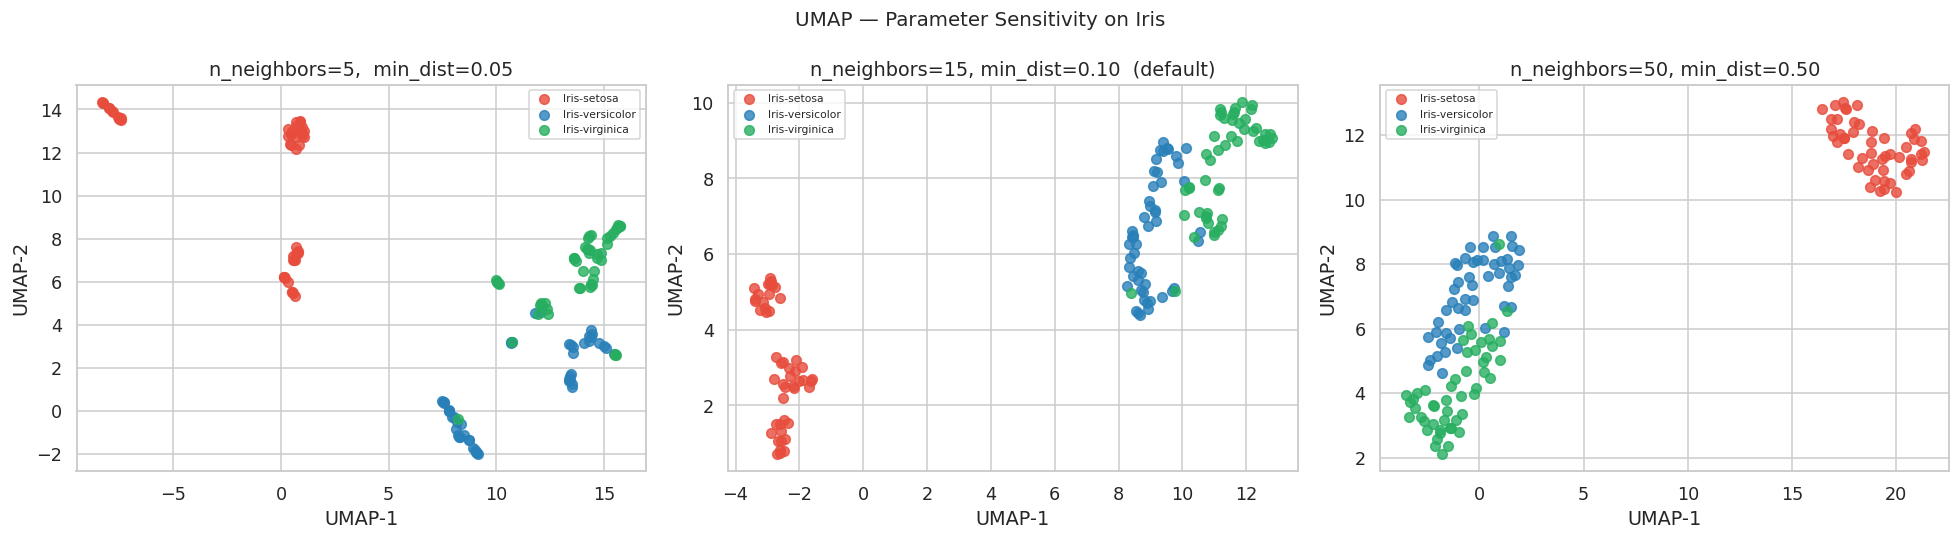

UMAP code above is ready — install umap-learn and remove the comments.

UMAP parameter intuition:
  n_neighbors=5  → captures very local detail, fragmented clusters
  n_neighbors=15 → balanced, usually best default
  n_neighbors=50 → smoother, more global, merges fine structure

  min_dist=0.05  → tight, compact clusters
  min_dist=0.50  → spread-out, more uniform distribution


In [12]:
# ── UMAP on Iris  (un-comment after: pip install umap-learn) ──────────────────
import umap

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    dict(n_neighbors=5,  min_dist=0.05, label='n_neighbors=5,  min_dist=0.05'),
    dict(n_neighbors=15, min_dist=0.10, label='n_neighbors=15, min_dist=0.10  (default)'),
    dict(n_neighbors=50, min_dist=0.50, label='n_neighbors=50, min_dist=0.50'),
]
for ax, cfg in zip(axes, configs):
    reducer = umap.UMAP(n_neighbors=cfg['n_neighbors'],
                        min_dist=cfg['min_dist'],
                        random_state=42)
    Z_umap = reducer.fit_transform(X_scaled)
    for sp in labels_iris:
        mask = y_iris == sp
        ax.scatter(Z_umap[mask,0], Z_umap[mask,1],
                   label=sp, alpha=0.8, s=40, color=colors[sp])
    ax.set(title=cfg['label'], xlabel='UMAP-1', ylabel='UMAP-2')
    ax.legend(fontsize=7)
plt.suptitle('UMAP — Parameter Sensitivity on Iris', fontsize=13)
plt.tight_layout(); plt.show()

print("UMAP code above is ready — install umap-learn and remove the comments.")
print()
print("UMAP parameter intuition:")
print("  n_neighbors=5  → captures very local detail, fragmented clusters")
print("  n_neighbors=15 → balanced, usually best default")
print("  n_neighbors=50 → smoother, more global, merges fine structure")
print()
print("  min_dist=0.05  → tight, compact clusters")
print("  min_dist=0.50  → spread-out, more uniform distribution")

---
## A5 · Feature Selection vs Feature Extraction

Both reduce dimensionality, but they differ fundamentally in *what* they keep.

### Feature Selection
Chooses a **subset of the original features** and discards the rest.
- Advantages: results remain interpretable in the original feature language.
- Methods: variance thresholds, correlation filters, mutual information, Recursive Feature
  Elimination (RFE), LASSO regularisation.

### Feature Extraction
Creates **new features** as mathematical transformations of the originals.
- Advantages: can compress information far more efficiently; often better for downstream models.
- Methods: PCA, t-SNE, UMAP, Autoencoders, LDA.

### When to use which?
```
Need to explain output in original terms?  →  Feature Selection
Need maximum compression / visualisation?  →  Feature Extraction (PCA / t-SNE / UMAP)
High-dimensional images or text?           →  Feature Extraction (Autoencoders)
```


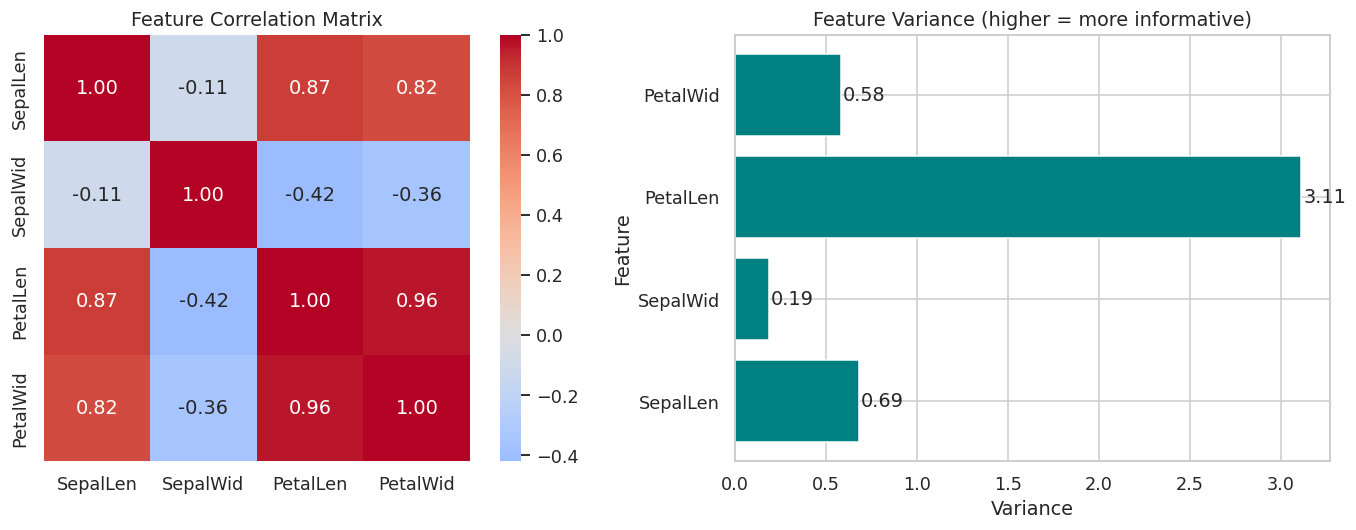

Correlation insight:
  PetalLen & PetalWid have r=0.96 → nearly redundant.
  Dropping one of them (feature selection) loses little information.

Variance insight:
  PetalLen has the highest variance → most discriminative single feature.
  PCA (extraction) would find a linear combo of all four that does even better.


In [13]:
# ── Feature Selection demo: correlation-based filtering on Iris ───────────────
iris_df  = pd.DataFrame(X_iris, columns=['SepalLen','SepalWid','PetalLen','PetalWid'])
corr_mat = iris_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Feature Correlation Matrix')

# Feature variance (simple selector)
variances = iris_df.var()
axes[1].barh(variances.index, variances.values, color='teal', edgecolor='white')
axes[1].set(title='Feature Variance (higher = more informative)',
            xlabel='Variance', ylabel='Feature')
for i, v in enumerate(variances.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout(); plt.show()

print("Correlation insight:")
print("  PetalLen & PetalWid have r=0.96 → nearly redundant.")
print("  Dropping one of them (feature selection) loses little information.")
print()
print("Variance insight:")
print("  PetalLen has the highest variance → most discriminative single feature.")
print("  PCA (extraction) would find a linear combo of all four that does even better.")

---
## A6 · Using PCA Before Clustering

Clustering algorithms like K-Means use Euclidean distance. In high dimensions distances
become uniformly large (curse of dimensionality), degrading cluster quality. PCA + clustering
is a two-step pipeline that:

1. **PCA** → compresses data, removes noise, makes distance metrics meaningful.
2. **K-Means** → clusters in the clean, low-dimensional space.

The standard workflow:
```
Raw data → Standardise → PCA (keep 95 % variance) → K-Means → Evaluate
```


Original (4D)         →  silhouette = 0.4590
PCA 2D                →  silhouette = 0.5082
PCA 3D                →  silhouette = 0.4651


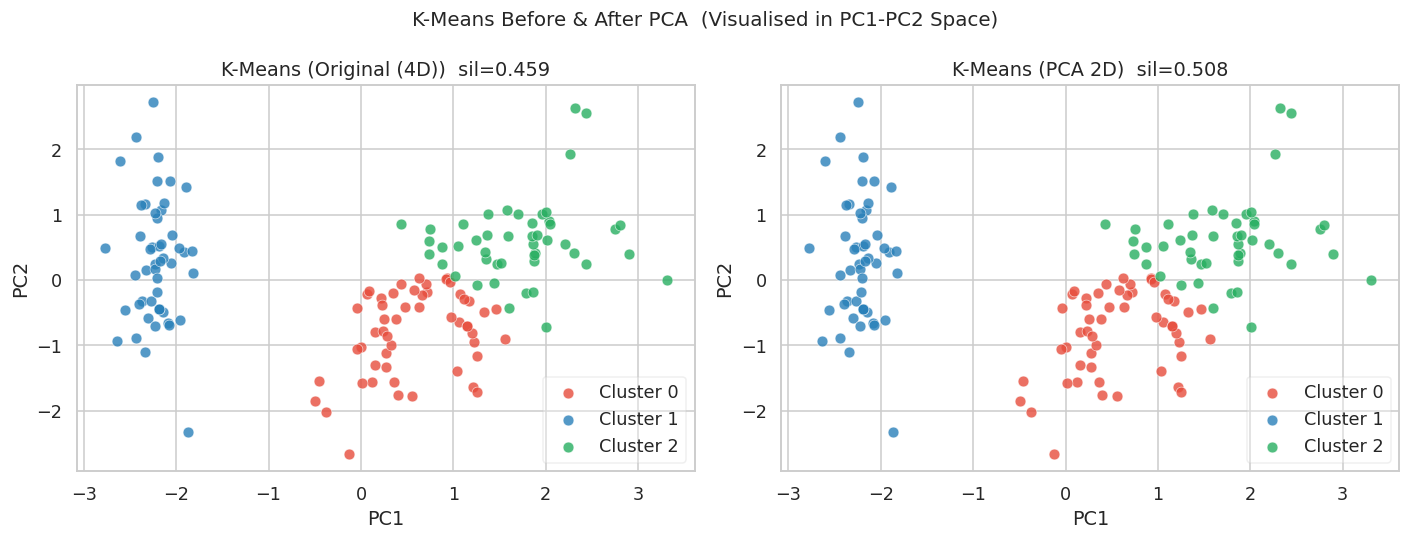


Both approaches recover the 3 species well, but PCA pre-processing
provides cleaner boundaries by removing noisy correlated dimensions.


In [14]:
# ── PCA → K-Means pipeline on Iris ────────────────────────────────────────────
k = 3   # we know there are 3 species

results = {}
for name, X_in in [('Original (4D)', X_scaled),
                   ('PCA 2D',        Z2),
                   ('PCA 3D',        Z3)]:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_in)
    sil  = silhouette_score(X_in, lbls)
    results[name] = {'labels': lbls, 'silhouette': sil}
    print(f"{name:20s}  →  silhouette = {sil:.4f}")

# ── Visualise cluster assignments in 2D PCA space ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cluster_colors = ['#e74c3c', '#2980b9', '#27ae60']

for ax, key in zip(axes, ['Original (4D)', 'PCA 2D']):
    lbls = results[key]['labels']
    for c in range(k):
        mask = lbls == c
        ax.scatter(Z2[mask, 0], Z2[mask, 1], alpha=0.8, s=50,
                   label=f'Cluster {c}', color=cluster_colors[c],
                   edgecolors='white', linewidths=0.4)
    ax.set(title=f'K-Means ({key})  sil={results[key]["silhouette"]:.3f}',
           xlabel='PC1', ylabel='PC2')
    ax.legend(framealpha=0.3)

plt.suptitle('K-Means Before & After PCA  (Visualised in PC1-PC2 Space)', fontsize=13)
plt.tight_layout(); plt.show()

print()
print("Both approaches recover the 3 species well, but PCA pre-processing")
print("provides cleaner boundaries by removing noisy correlated dimensions.")

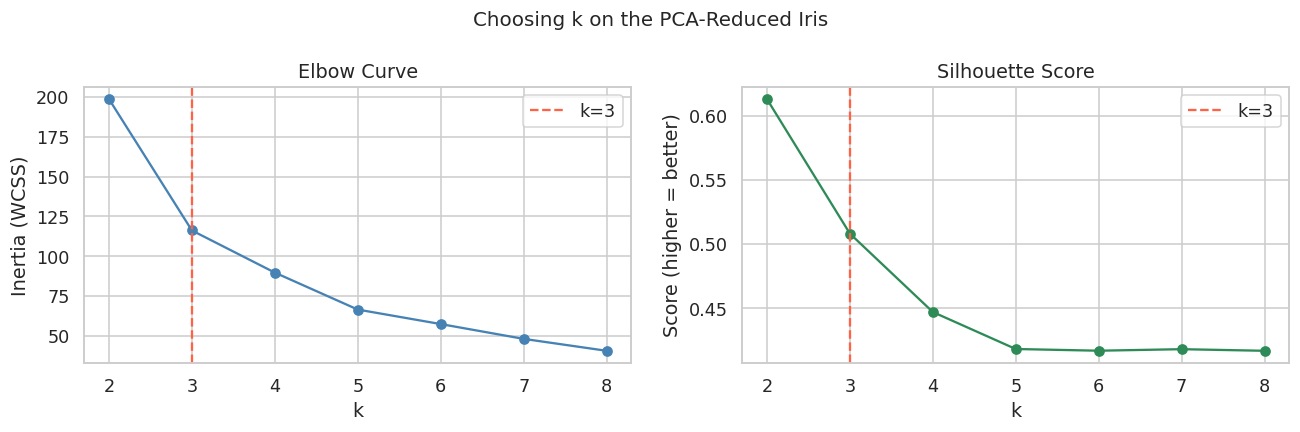

Both the elbow (inertia flattens) and the silhouette peak confirm k=3.


In [15]:
# ── Elbow method: choosing k ──────────────────────────────────────────────────
inertias, sils = [], []
K_range = range(2, 9)
for k_ in K_range:
    km    = KMeans(n_clusters=k_, random_state=42, n_init=10)
    lbls  = km.fit_predict(Z2)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z2, lbls))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set(title='Elbow Curve', xlabel='k', ylabel='Inertia (WCSS)')
axes[0].axvline(3, linestyle='--', color='tomato', label='k=3')
axes[0].legend()

axes[1].plot(K_range, sils, 'o-', color='seagreen')
axes[1].set(title='Silhouette Score', xlabel='k', ylabel='Score (higher = better)')
axes[1].axvline(3, linestyle='--', color='tomato', label='k=3')
axes[1].legend()

plt.suptitle('Choosing k on the PCA-Reduced Iris', fontsize=13)
plt.tight_layout(); plt.show()
print("Both the elbow (inertia flattens) and the silhouette peak confirm k=3.")

---
# Part B — Anomaly Detection

---

## B1 · What Is an Anomaly?

An **anomaly** (also called an *outlier*) is a data point that deviates significantly
from the expected behaviour. In the context of our embedded-system network-security
dataset, anomalies are network packets that behave differently from normal traffic —
a possible sign of an intrusion, sensor fault, or communication error.

Anomaly detection matters because:
- Attacks and faults are **rare** → supervised models trained on balanced data often fail.
- Labels may be **unavailable** → we must learn what "normal" looks like without knowing
  what attacks look like.

### Three Types of Anomalies

**1 · Point anomaly**  
A single data point is anomalous with respect to the rest of the data.  
*Example:* a single packet with an impossibly large `packet_size`.

**2 · Contextual anomaly**  
A data point is anomalous *in context* but would be normal elsewhere.  
*Example:* a burst of UDP packets during a maintenance window is normal, but the same
burst at 3 AM is suspicious.

**3 · Collective anomaly**  
A collection of data points is anomalous together, even if individual points look normal.  
*Example:* ten packets each individually within normal ranges, but together forming a
port-scan pattern.

---

## B2 · Isolation Forest

### How it works
**Isolation Forest** (Liu et al., 2008) is one of the most practical and scalable
anomaly-detection algorithms. Its key insight is:

> Anomalies are *few and different* — they are **easier to isolate** than normal points.

The algorithm builds an ensemble of **Isolation Trees**:

1. Randomly select a feature $f$ from the dataset.
2. Randomly select a split value $s$ between the minimum and maximum of $f$.
3. Partition the data: points with $f < s$ go left, others go right.
4. Repeat recursively until each point is isolated (alone in a leaf).

**Anomaly score:** the average *path length* to isolate a point across all trees.
- **Short path** → isolated quickly → **anomalous** (the point lives in a sparse region).
- **Long path** → hard to isolate → **normal** (the point lives in a dense region).

### Advantages
- Works in original feature space — no distance metric needed.
- Linear time complexity $O(n \log n)$.
- Handles high-dimensional data well.
- Naturally robust to the curse of dimensionality.

### Key parameters
| Parameter | Effect |
|---|---|
| `n_estimators` | Number of trees. More → more stable scores. Default: 100. |
| `contamination` | Expected fraction of outliers. Set based on domain knowledge. |
| `max_samples` | Points sampled per tree. `'auto'` = min(256, n). |


In [16]:
# ── Prepare network security features ─────────────────────────────────────────
feature_names = list(sec_raw.drop(columns=['label']).columns)
scaler_sec    = StandardScaler()
X_sec_scaled  = scaler_sec.fit_transform(X_sec)

# ── Isolation Forest ──────────────────────────────────────────────────────────
contamination_rate = 0.10          # we know 10% are anomalies

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    max_samples='auto',
    random_state=42
)
iso_scores  = iso_forest.fit(X_sec_scaled).decision_function(X_sec_scaled)
iso_preds   = iso_forest.predict(X_sec_scaled)   # +1 normal, -1 anomaly
iso_binary  = np.where(iso_preds == -1, 1, 0)    # 1=anomaly to match y_sec

print("=== Isolation Forest Results ===")
print(f"Predicted anomalies : {iso_binary.sum()}")
print(f"True anomalies      : {y_sec.sum()}")
print()
print(classification_report(y_sec, iso_binary, target_names=['Normal', 'Anomaly']))

=== Isolation Forest Results ===
Predicted anomalies : 100
True anomalies      : 100

              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90       900
     Anomaly       0.11      0.11      0.11       100

    accuracy                           0.82      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.82      0.82      0.82      1000



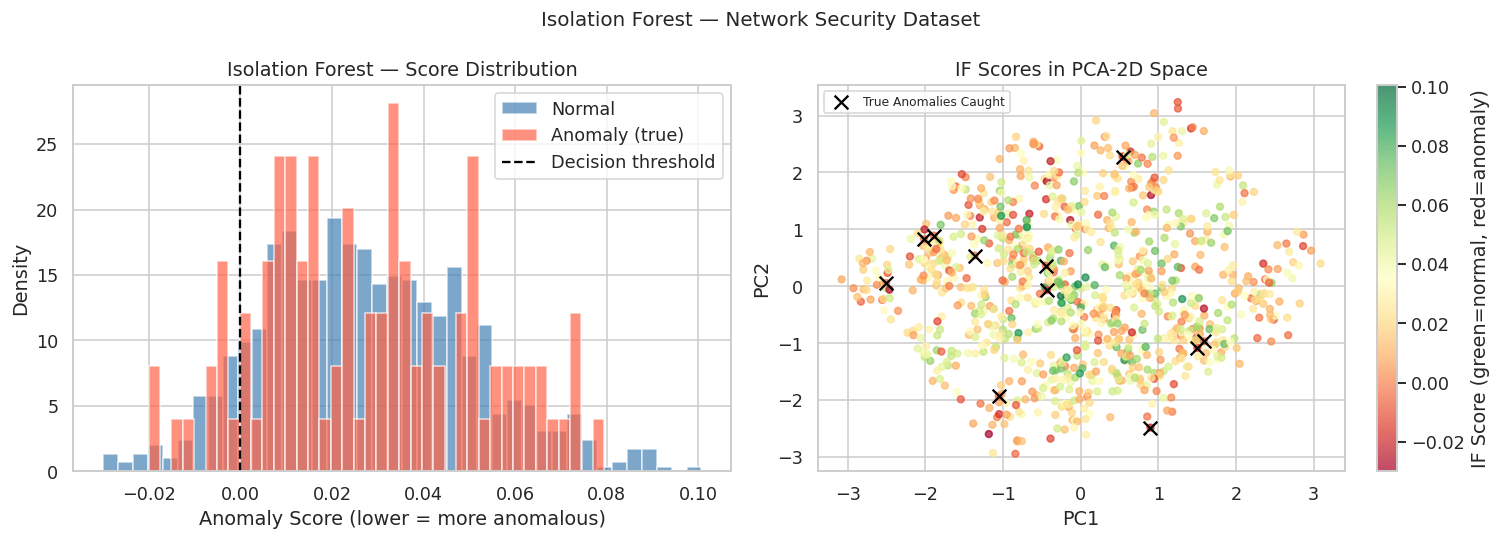

In [17]:
# ── Visualise Isolation Forest anomaly scores ─────────────────────────────────
# Use PCA-2D of the security data for visualisation
pca_sec  = PCA(n_components=2, random_state=42)
Z_sec_2d = pca_sec.fit_transform(X_sec_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution
axes[0].hist(iso_scores[y_sec == 0], bins=40, alpha=0.7, color='steelblue',
             label='Normal', density=True)
axes[0].hist(iso_scores[y_sec == 1], bins=40, alpha=0.7, color='tomato',
             label='Anomaly (true)', density=True)
axes[0].axvline(0, linestyle='--', color='black', label='Decision threshold')
axes[0].set(title='Isolation Forest — Score Distribution',
            xlabel='Anomaly Score (lower = more anomalous)', ylabel='Density')
axes[0].legend()

# 2D scatter in PCA space
sc = axes[1].scatter(Z_sec_2d[:, 0], Z_sec_2d[:, 1],
                     c=iso_scores, cmap='RdYlGn', s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='IF Score (green=normal, red=anomaly)')
# overlay true positives (caught anomalies)
tp_mask = (iso_binary == 1) & (y_sec == 1)
axes[1].scatter(Z_sec_2d[tp_mask, 0], Z_sec_2d[tp_mask, 1],
                marker='x', s=80, c='black', label='True Anomalies Caught')
axes[1].set(title='IF Scores in PCA-2D Space', xlabel='PC1', ylabel='PC2')
axes[1].legend(fontsize=8)

plt.suptitle('Isolation Forest — Network Security Dataset', fontsize=13)
plt.tight_layout(); plt.show()

---
## B3 · One-Class SVM for Outlier Detection

### Intuition
In standard binary SVM we find a hyperplane that **separates two classes**.
**One-Class SVM** (Schölkopf et al., 2001) has only *one* class to learn: the normal data.
It finds the **tightest hypersphere** (or hyperplane in feature space) that encloses
most of the training data. Points falling outside that boundary are flagged as anomalies.

### The kernel trick
In the original feature space a hypersphere may not separate normal from abnormal.
Using an **RBF (Gaussian) kernel**, One-Class SVM implicitly maps data into a much
higher-dimensional space where a tight hyperplane *does* separate the data from the
origin, which is equivalent to enclosing the data in a sphere in the original space.

### Key parameters
| Parameter | Effect |
|---|---|
| `kernel` | `'rbf'` (default) works for most cases. |
| `nu` (0–1) | Upper bound on the fraction of outliers AND a lower bound on the fraction of support vectors. Set close to expected contamination. |
| `gamma` | RBF kernel width. `'scale'` or `'auto'` are safe starting points. |

### Strengths & weaknesses
- Works well in moderate dimensions.
- **Sensitive to scaling** — always standardise first.
- **Slow on large datasets** — $O(n^2)$ to $O(n^3)$ training.
- Not ideal when the normal class is highly multi-modal.


In [18]:
# ── One-Class SVM ─────────────────────────────────────────────────────────────
# Train only on data we suspect is normal (using y_sec labels for demonstration)
# In a real scenario you would train on unlabelled data.
X_train_normal = X_sec_scaled[y_sec == 0]

ocsvm = OneClassSVM(kernel='rbf', nu=0.10, gamma='scale')
ocsvm.fit(X_train_normal)

ocsvm_preds   = ocsvm.predict(X_sec_scaled)   # +1 = normal, -1 = anomaly
ocsvm_binary  = np.where(ocsvm_preds == -1, 1, 0)
ocsvm_scores  = ocsvm.decision_function(X_sec_scaled)  # signed distance to boundary

print("=== One-Class SVM Results ===")
print(f"Predicted anomalies : {ocsvm_binary.sum()}")
print(f"True anomalies      : {y_sec.sum()}")
print()
print(classification_report(y_sec, ocsvm_binary, target_names=['Normal', 'Anomaly']))

=== One-Class SVM Results ===
Predicted anomalies : 115
True anomalies      : 100

              precision    recall  f1-score   support

      Normal       0.91      0.89      0.90       900
     Anomaly       0.16      0.18      0.17       100

    accuracy                           0.82      1000
   macro avg       0.53      0.54      0.53      1000
weighted avg       0.83      0.82      0.83      1000



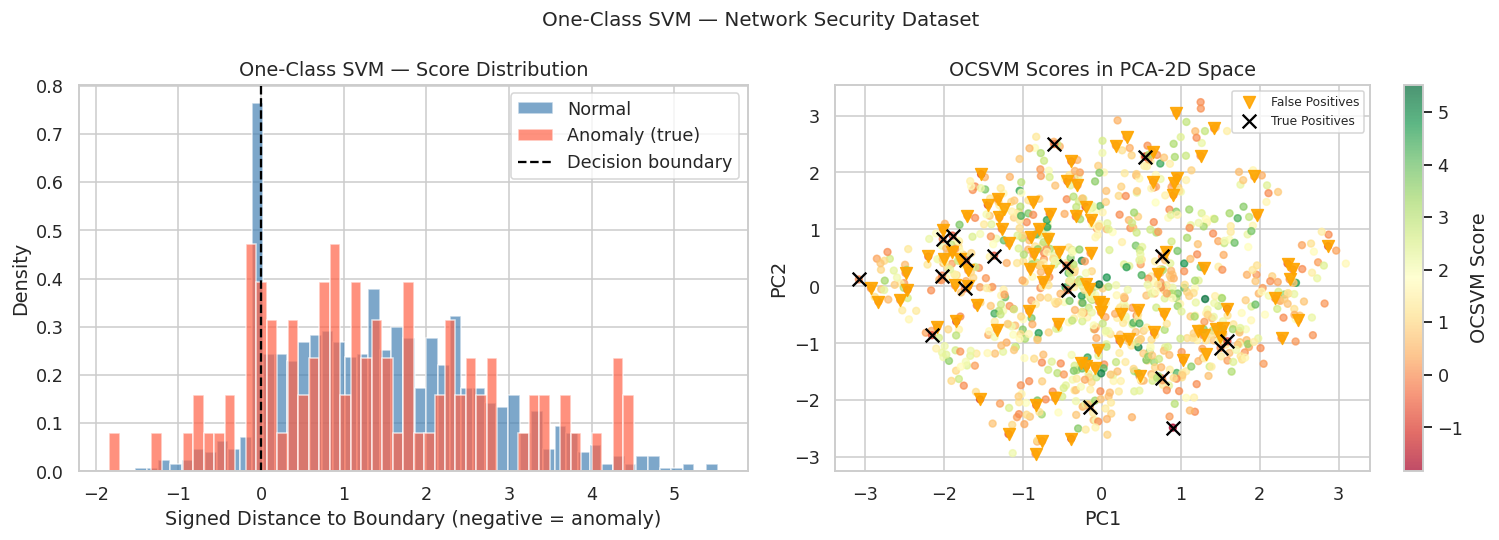

In [19]:
# ── OCSVM score visualisation ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ocsvm_scores[y_sec == 0], bins=50, alpha=0.7, color='steelblue',
             label='Normal', density=True)
axes[0].hist(ocsvm_scores[y_sec == 1], bins=50, alpha=0.7, color='tomato',
             label='Anomaly (true)', density=True)
axes[0].axvline(0, linestyle='--', color='black', label='Decision boundary')
axes[0].set(title='One-Class SVM — Score Distribution',
            xlabel='Signed Distance to Boundary (negative = anomaly)', ylabel='Density')
axes[0].legend()

# 2D scatter
sc = axes[1].scatter(Z_sec_2d[:,0], Z_sec_2d[:,1],
                     c=ocsvm_scores, cmap='RdYlGn', s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='OCSVM Score')
fp_mask = (ocsvm_binary == 1) & (y_sec == 0)
axes[1].scatter(Z_sec_2d[fp_mask, 0], Z_sec_2d[fp_mask, 1],
                marker='v', s=60, c='orange', label='False Positives', alpha=0.9)
axes[1].scatter(Z_sec_2d[(ocsvm_binary==1)&(y_sec==1), 0],
                Z_sec_2d[(ocsvm_binary==1)&(y_sec==1), 1],
                marker='x', s=80, c='black', label='True Positives')
axes[1].set(title='OCSVM Scores in PCA-2D Space', xlabel='PC1', ylabel='PC2')
axes[1].legend(fontsize=8)
plt.suptitle('One-Class SVM — Network Security Dataset', fontsize=13)
plt.tight_layout(); plt.show()

---
## B4 · Local Outlier Factor (LOF)

### Intuition
**LOF** (Breunig et al., 2000) takes a *density-based* view of anomalies.

> A point is an outlier if its **local density** is much lower than the density of
> its neighbours.

The key word is *local*: LOF can detect anomalies that live in regions of generally
low density — something that global methods like One-Class SVM struggle with.

### How it works, step by step
1. For each point $p$, find its $k$ nearest neighbours.
2. Compute the **reachability distance** between $p$ and each neighbour (a smoothed
   distance that avoids statistical fluctuations for very close points).
3. Compute the **local reachability density** (LRD) of $p$: the inverse of the average
   reachability distance to its neighbours. High LRD = dense region.
4. Compute the **LOF score**: the ratio of the average LRD of $p$'s neighbours to
   the LRD of $p$.
   - LOF ≈ 1 → $p$ has similar density to its neighbours → **normal**.
   - LOF >> 1 → $p$ is much less dense than its neighbours → **outlier**.

### Key parameters
| Parameter | Effect |
|---|---|
| `n_neighbors` | Size of the neighbourhood. Typical: 20. |
| `contamination` | Fraction of expected outliers (sets the decision threshold). |
| `metric` | Distance metric. Default `'minkowski'` (reduces to Euclidean for p=2). |

### Strengths & weaknesses
- Excellent at detecting outliers in **locally sparse** regions.
- Handles non-spherical cluster shapes.
- $O(n^2)$ — slow for large $n$.
- `novelty=False` means you cannot predict on new unseen data; `novelty=True` allows
  prediction but requires fitting on normal data only.


In [20]:
# ── Local Outlier Factor ──────────────────────────────────────────────────────
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10, metric='euclidean')
lof_preds  = lof.fit_predict(X_sec_scaled)      # +1 normal, -1 anomaly
lof_binary = np.where(lof_preds == -1, 1, 0)
lof_scores = -lof.negative_outlier_factor_       # higher = more anomalous

print("=== Local Outlier Factor Results ===")
print(f"Predicted anomalies : {lof_binary.sum()}")
print(f"True anomalies      : {y_sec.sum()}")
print()
print(classification_report(y_sec, lof_binary, target_names=['Normal', 'Anomaly']))

=== Local Outlier Factor Results ===
Predicted anomalies : 100
True anomalies      : 100

              precision    recall  f1-score   support

      Normal       0.90      0.90      0.90       900
     Anomaly       0.08      0.08      0.08       100

    accuracy                           0.82      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.82      0.82      0.82      1000



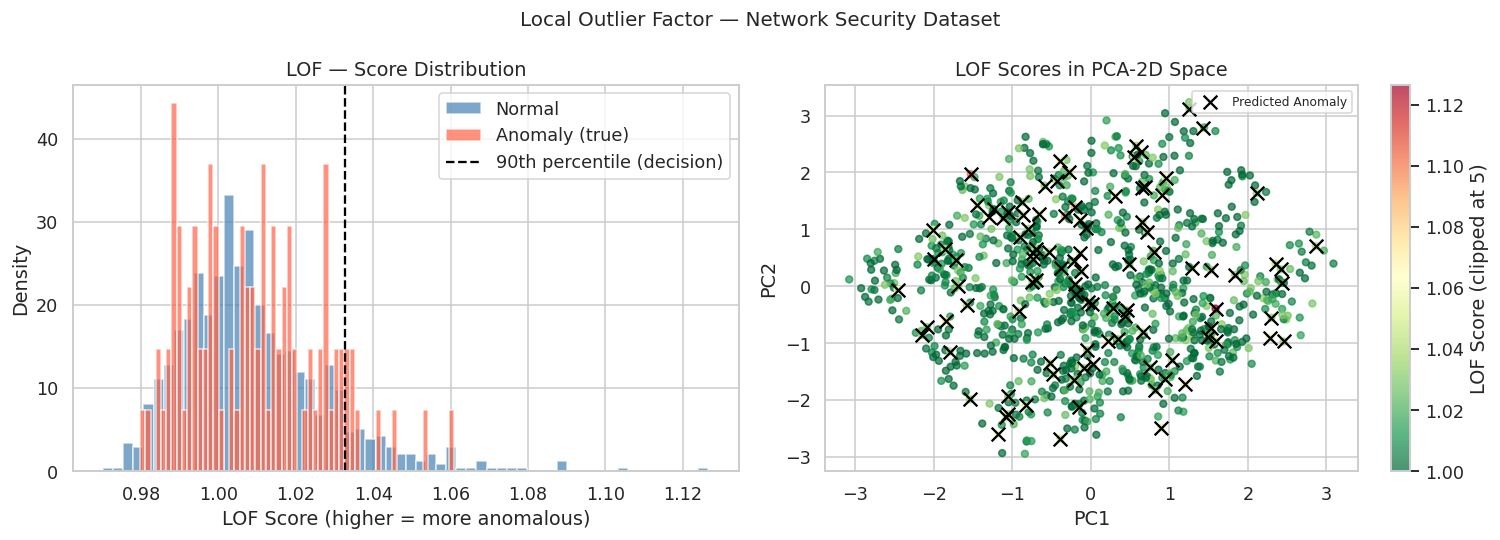

In [21]:
# ── LOF score visualisation ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(lof_scores[y_sec == 0], bins=60, alpha=0.7, color='steelblue',
             label='Normal', density=True)
axes[0].hist(lof_scores[y_sec == 1], bins=60, alpha=0.7, color='tomato',
             label='Anomaly (true)', density=True)
axes[0].axvline(np.percentile(lof_scores, 90), linestyle='--', color='black',
                label='90th percentile (decision)')
axes[0].set(title='LOF — Score Distribution',
            xlabel='LOF Score (higher = more anomalous)', ylabel='Density')
axes[0].legend()

sc = axes[1].scatter(Z_sec_2d[:,0], Z_sec_2d[:,1],
                     c=np.clip(lof_scores, 1, 5), cmap='RdYlGn_r',
                     s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='LOF Score (clipped at 5)')
axes[1].scatter(Z_sec_2d[lof_binary==1, 0], Z_sec_2d[lof_binary==1, 1],
                marker='x', s=80, c='black', label='Predicted Anomaly')
axes[1].set(title='LOF Scores in PCA-2D Space', xlabel='PC1', ylabel='PC2')
axes[1].legend(fontsize=8)
plt.suptitle('Local Outlier Factor — Network Security Dataset', fontsize=13)
plt.tight_layout(); plt.show()

---
## B5 · Autoencoders for Anomaly Detection — Preview

### What is an Autoencoder?
An **autoencoder** is a neural network trained to *reconstruct its own input*.

```
Input X  →  [Encoder]  →  Bottleneck z  →  [Decoder]  →  Reconstructed X̂
```

- The **encoder** compresses $X$ into a low-dimensional latent code $z$.
- The **decoder** expands $z$ back to the original dimensionality.
- The network is trained to minimise **reconstruction error** $\|X - \hat{X}\|^2$.

### Why does this detect anomalies?
The autoencoder is trained **only on normal data**. It learns to compress and reconstruct
the patterns in normal traffic. When an anomalous packet is fed in, the decoder cannot
reconstruct it well (it has never seen such a pattern during training), so the
reconstruction error is **high**. We use that error as an anomaly score.

```
High reconstruction error  →  Point does not fit learned normal patterns  →  Anomaly
```

### Architecture for tabular data
```
Input (17 features)
  ↓  Dense(32, ReLU)   ← Encoder
  ↓  Dense(16, ReLU)
  ↓  Dense(8,  ReLU)   ← Bottleneck (latent space)
  ↓  Dense(16, ReLU)   ← Decoder
  ↓  Dense(32, ReLU)
  ↓  Dense(17, Linear) ← Reconstruction
```

### Numpy-only Autoencoder Simulation
Since TensorFlow/PyTorch are not available in this environment, the cell below
implements a **single-layer linear autoencoder** using only NumPy (mathematically
equivalent to PCA). This demonstrates the *reconstruction error* concept correctly.
A full deep autoencoder would require TensorFlow or PyTorch; the code is provided
commented below for your local environment.


In [22]:
# ── Linear Autoencoder (PCA-equivalent) using SVD — runs without deep learning ─
# This is mathematically equivalent to a linear autoencoder with MSE loss.
# A deep nonlinear autoencoder would use TensorFlow/PyTorch (code below in comments).

# Train only on normal traffic
X_normal = X_sec_scaled[y_sec == 0]
X_all    = X_sec_scaled

# SVD of the normal data (≡ PCA)
bottleneck_dim = 6   # compress 17 features → 6 latent dims
U, S, Vt = np.linalg.svd(X_normal, full_matrices=False)
components = Vt[:bottleneck_dim]   # top-6 principal directions

# Encode then decode (linear autoencoder)
Z_encoded    = X_all @ components.T         # project to bottleneck
X_hat        = Z_encoded @ components       # reconstruct

# Reconstruction error per sample
recon_error  = np.mean((X_all - X_hat) ** 2, axis=1)

# Threshold: 95th percentile of normal reconstruction error
threshold = np.percentile(recon_error[y_sec == 0], 95)
ae_binary = (recon_error > threshold).astype(int)

print("=== Linear Autoencoder (SVD-based) Results ===")
print(f"Bottleneck dim       : {bottleneck_dim} / 17")
print(f"Anomaly threshold    : {threshold:.4f}")
print(f"Predicted anomalies  : {ae_binary.sum()}")
print(f"True anomalies       : {y_sec.sum()}")
print()
print(classification_report(y_sec, ae_binary, target_names=['Normal', 'Anomaly']))

=== Linear Autoencoder (SVD-based) Results ===
Bottleneck dim       : 6 / 17
Anomaly threshold    : 0.6848
Predicted anomalies  : 53
True anomalies       : 100

              precision    recall  f1-score   support

      Normal       0.90      0.95      0.93       900
     Anomaly       0.15      0.08      0.10       100

    accuracy                           0.86      1000
   macro avg       0.53      0.52      0.52      1000
weighted avg       0.83      0.86      0.84      1000



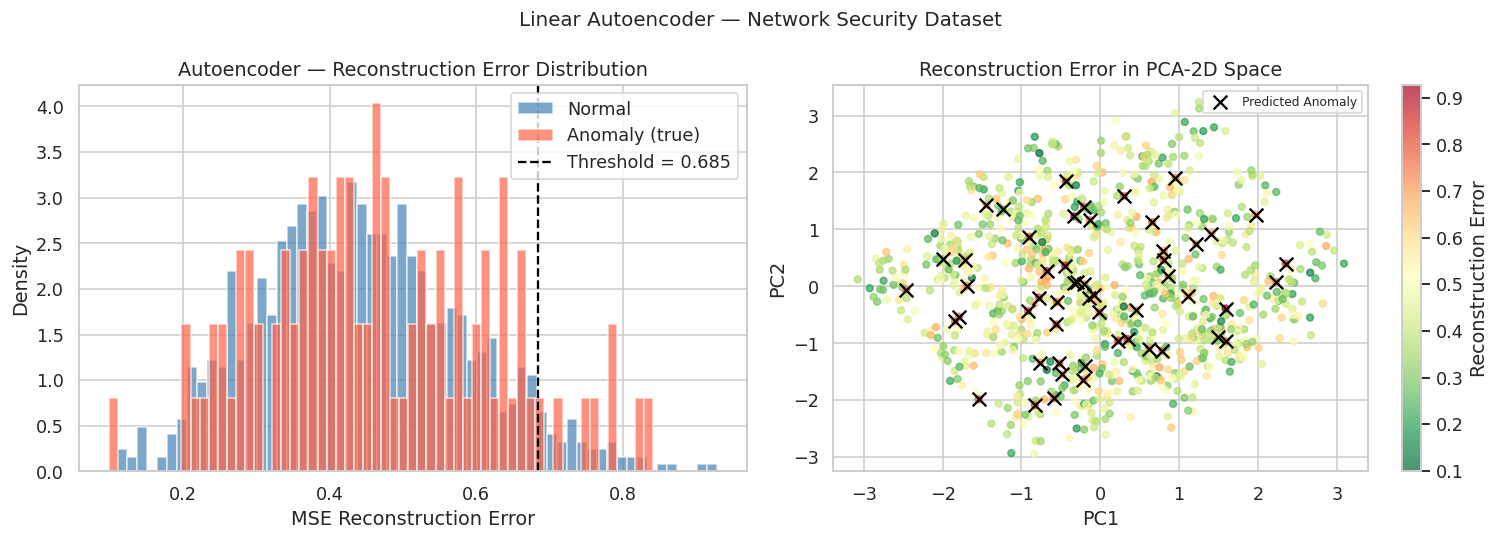

In [23]:
# ── Reconstruction error visualisation ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(recon_error[y_sec==0], bins=60, alpha=0.7, color='steelblue',
             label='Normal', density=True)
axes[0].hist(recon_error[y_sec==1], bins=60, alpha=0.7, color='tomato',
             label='Anomaly (true)', density=True)
axes[0].axvline(threshold, linestyle='--', color='black',
                label=f'Threshold = {threshold:.3f}')
axes[0].set(title='Autoencoder — Reconstruction Error Distribution',
            xlabel='MSE Reconstruction Error', ylabel='Density')
axes[0].legend()

sc = axes[1].scatter(Z_sec_2d[:,0], Z_sec_2d[:,1],
                     c=recon_error, cmap='RdYlGn_r', s=20, alpha=0.7)
plt.colorbar(sc, ax=axes[1], label='Reconstruction Error')
axes[1].scatter(Z_sec_2d[ae_binary==1, 0], Z_sec_2d[ae_binary==1, 1],
                marker='x', s=80, c='black', label='Predicted Anomaly')
axes[1].set(title='Reconstruction Error in PCA-2D Space', xlabel='PC1', ylabel='PC2')
axes[1].legend(fontsize=8)
plt.suptitle('Linear Autoencoder — Network Security Dataset', fontsize=13)
plt.tight_layout(); plt.show()

In [24]:
#── Deep Autoencoder with TensorFlow (un-comment in your local environment) ───
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

def build_autoencoder(input_dim, bottleneck=6):
    inp = tf.keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(32, activation='relu')(inp)
    x = layers.Dense(16, activation='relu')(x)
    z = layers.Dense(bottleneck, activation='relu', name='bottleneck')(x)
    # Decoder
    x = layers.Dense(16, activation='relu')(z)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    return Model(inp, out)

ae = build_autoencoder(X_sec_scaled.shape[1], bottleneck=6)
ae.compile(optimizer='adam', loss='mse')
ae.summary()

# Train on normal data only
early_stop = callbacks.EarlyStopping(patience=10, restore_best_weights=True)
ae.fit(X_normal, X_normal,
        epochs=100, batch_size=32, validation_split=0.1,
        callbacks=[early_stop], verbose=0)

X_hat_deep   = ae.predict(X_sec_scaled)
recon_deep   = np.mean((X_sec_scaled - X_hat_deep)**2, axis=1)
threshold_d  = np.percentile(recon_deep[y_sec==0], 95)
ae_deep_pred = (recon_deep > threshold_d).astype(int)
print(classification_report(y_sec, ae_deep_pred, target_names=['Normal','Anomaly']))

print("Deep Autoencoder code ready — install tensorflow and remove the comments.")
print("The linear SVD version above demonstrates the same reconstruction-error concept.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 6)              │           102 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 17)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423 (9.46 KB)

 Trainable params: 2,423 (9.46 KB)

 Non-trainable params: 0 (0.00 B)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.93       900
     Anomaly       0.18      0.10      0.13       100

    accuracy                           0.86      1000
   macro avg       0.54      0.53      0.53      1000
weighted avg       0.83      0.86      0.85      1000

Deep Autoencoder code ready — install tensorflow and remove the comments.
The linear SVD version above demonstrates the same reconstruction-error concept.


---
## B6 · Algorithm Comparison & Fraud/Error Detection Scenario

Now that all four algorithms have been applied, let's compare them side by side and
build a complete **fraud/error detection pipeline** that uses an ensemble approach.

### Scenario
> You are a security engineer at an IoT company. Your embedded systems send network
> packets every few milliseconds. You have 1 000 recent packets, of which you **do not
> know** which are attacks (in production there are no labels). Your goal: flag the top
> 10 % most suspicious packets for manual review.

The recommended production pipeline:
1. Standardise features.
2. Apply multiple detectors, each producing an anomaly score.
3. **Ensemble** by averaging normalised scores → reduces false positives.
4. Flag packets above the ensemble threshold.


In [25]:
# ── Normalise all scores to [0, 1] (higher = more anomalous) ─────────────────
from sklearn.preprocessing import MinMaxScaler

def norm(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

# Isolation Forest: lower decision_function → more anomalous → negate
score_if  = norm(-iso_scores)
# One-Class SVM: lower decision_function → more anomalous → negate
score_oc  = norm(-ocsvm_scores)
# LOF: higher score → more anomalous
score_lof = norm(lof_scores)
# Autoencoder: higher error → more anomalous
score_ae  = norm(recon_error)

# ── Ensemble: mean of normalised scores ──────────────────────────────────────
ensemble_score = (score_if + score_oc + score_lof + score_ae) / 4.0

thresh_ens = np.percentile(ensemble_score, 90)   # top 10% flagged
ens_binary = (ensemble_score > thresh_ens).astype(int)

print("=== Ensemble Anomaly Detection ===")
print(f"Flags raised (top 10%) : {ens_binary.sum()}")
print(f"True anomalies         : {y_sec.sum()}")
print()
print(classification_report(y_sec, ens_binary, target_names=['Normal', 'Anomaly']))

=== Ensemble Anomaly Detection ===
Flags raised (top 10%) : 100
True anomalies         : 100

              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91       900
     Anomaly       0.15      0.15      0.15       100

    accuracy                           0.83      1000
   macro avg       0.53      0.53      0.53      1000
weighted avg       0.83      0.83      0.83      1000



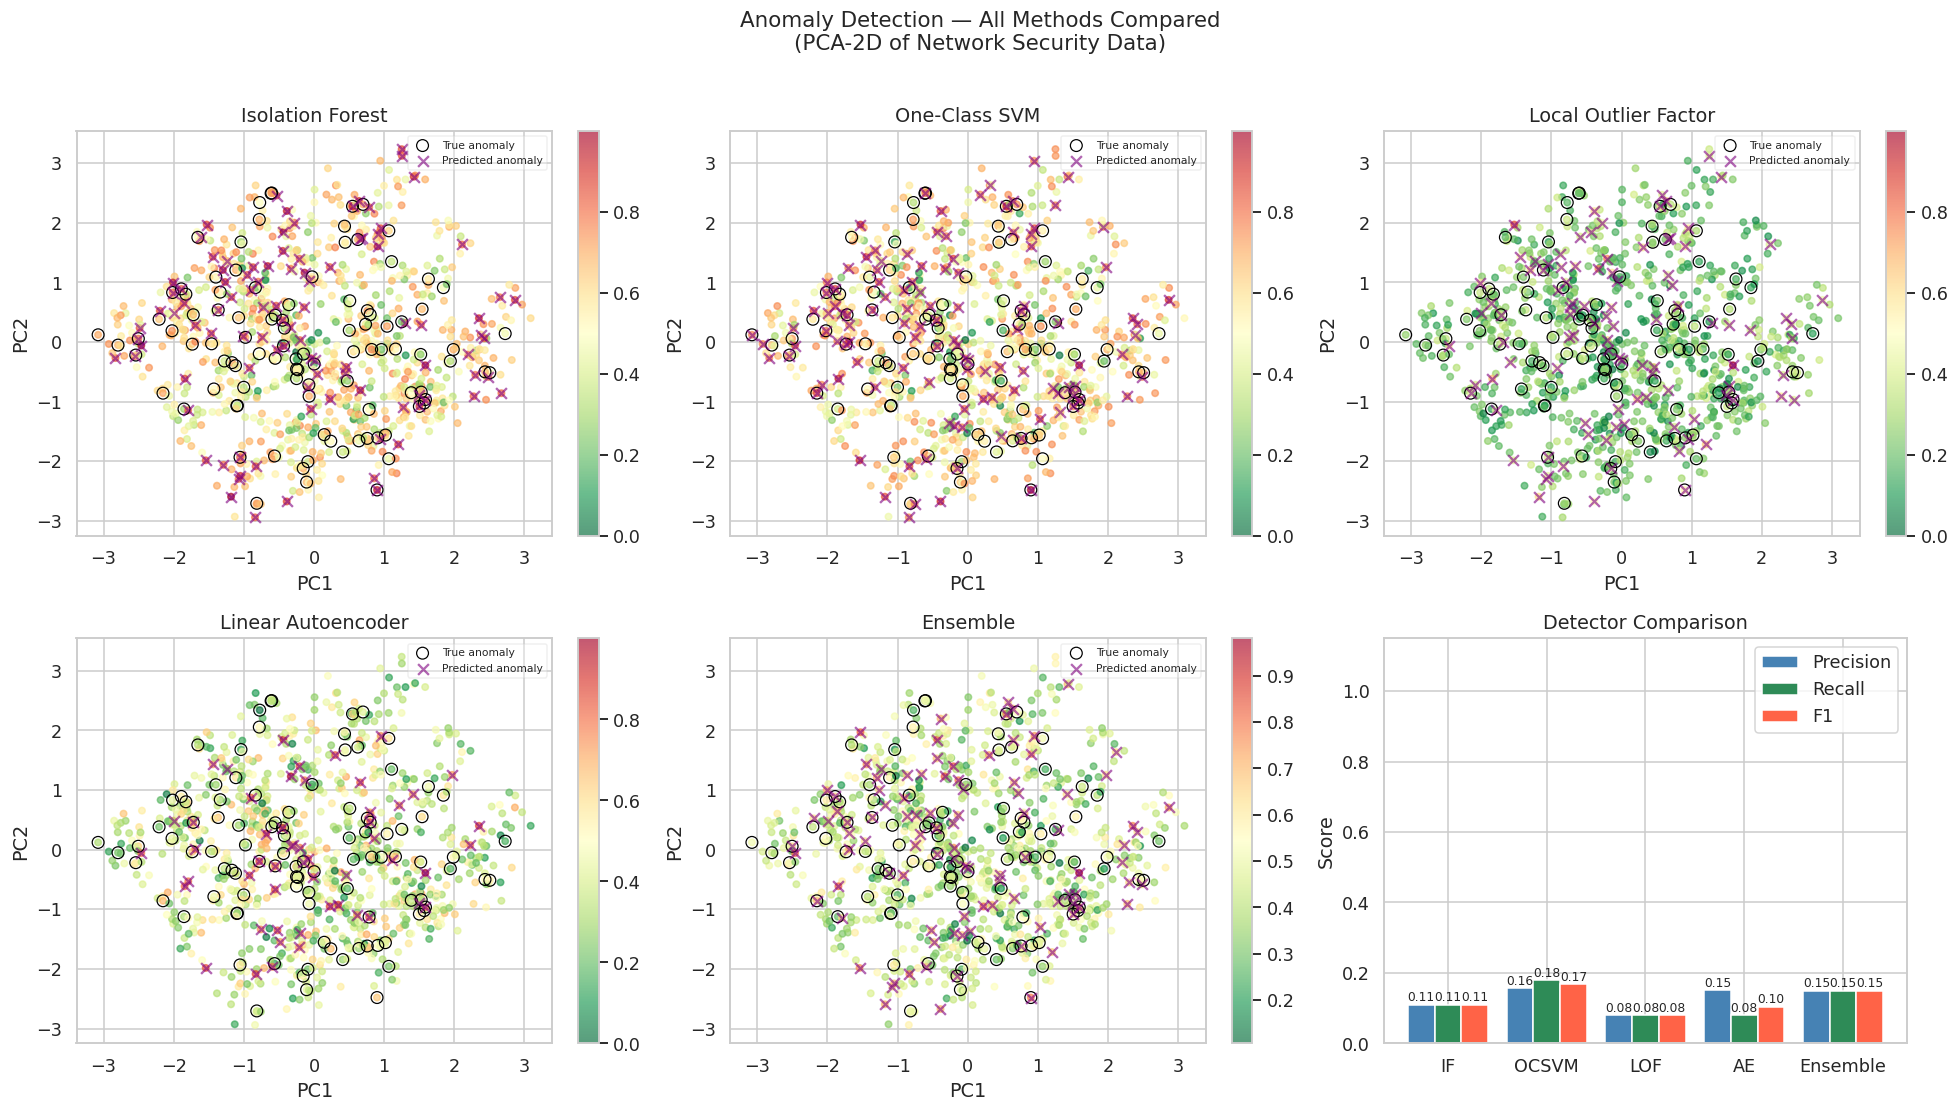

In [26]:
# ── Side-by-side comparison of all detectors ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

configs = [
    ('Isolation Forest',   iso_binary,   score_if),
    ('One-Class SVM',      ocsvm_binary, score_oc),
    ('Local Outlier Factor', lof_binary, score_lof),
    ('Linear Autoencoder', ae_binary,    score_ae),
    ('Ensemble',           ens_binary,   ensemble_score),
]

for ax, (title, pred, score) in zip(axes[:5], configs):
    sc = ax.scatter(Z_sec_2d[:,0], Z_sec_2d[:,1],
                    c=score, cmap='RdYlGn_r', s=18, alpha=0.65)
    ax.scatter(Z_sec_2d[y_sec==1, 0], Z_sec_2d[y_sec==1, 1],
               marker='o', s=60, facecolors='none', edgecolors='black',
               linewidths=0.8, label='True anomaly')
    ax.scatter(Z_sec_2d[pred==1, 0], Z_sec_2d[pred==1, 1],
               marker='x', s=50, c='purple', alpha=0.6, label='Predicted anomaly')
    plt.colorbar(sc, ax=ax, fraction=0.04)
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
    ax.legend(fontsize=7, framealpha=0.3)

# Summary bar chart in the 6th panel
detector_names = ['IF', 'OCSVM', 'LOF', 'AE', 'Ensemble']
from sklearn.metrics import f1_score, recall_score, precision_score
f1s       = [f1_score(y_sec, b)        for b in [iso_binary, ocsvm_binary, lof_binary, ae_binary, ens_binary]]
recalls   = [recall_score(y_sec, b)    for b in [iso_binary, ocsvm_binary, lof_binary, ae_binary, ens_binary]]
precs     = [precision_score(y_sec, b) for b in [iso_binary, ocsvm_binary, lof_binary, ae_binary, ens_binary]]

x = np.arange(len(detector_names))
w = 0.27
axes[5].bar(x - w, precs,   w, label='Precision', color='steelblue')
axes[5].bar(x,     recalls, w, label='Recall',    color='seagreen')
axes[5].bar(x + w, f1s,     w, label='F1',        color='tomato')
axes[5].set(title='Detector Comparison', ylabel='Score',
            xticks=x, xticklabels=detector_names)
axes[5].legend()
axes[5].set_ylim(0, 1.15)
for i, (p,r,f) in enumerate(zip(precs,recalls,f1s)):
    axes[5].text(i-w, p+0.01, f'{p:.2f}', ha='center', fontsize=8)
    axes[5].text(i,   r+0.01, f'{r:.2f}', ha='center', fontsize=8)
    axes[5].text(i+w, f+0.01, f'{f:.2f}', ha='center', fontsize=8)

plt.suptitle('Anomaly Detection — All Methods Compared\n(PCA-2D of Network Security Data)',
             fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

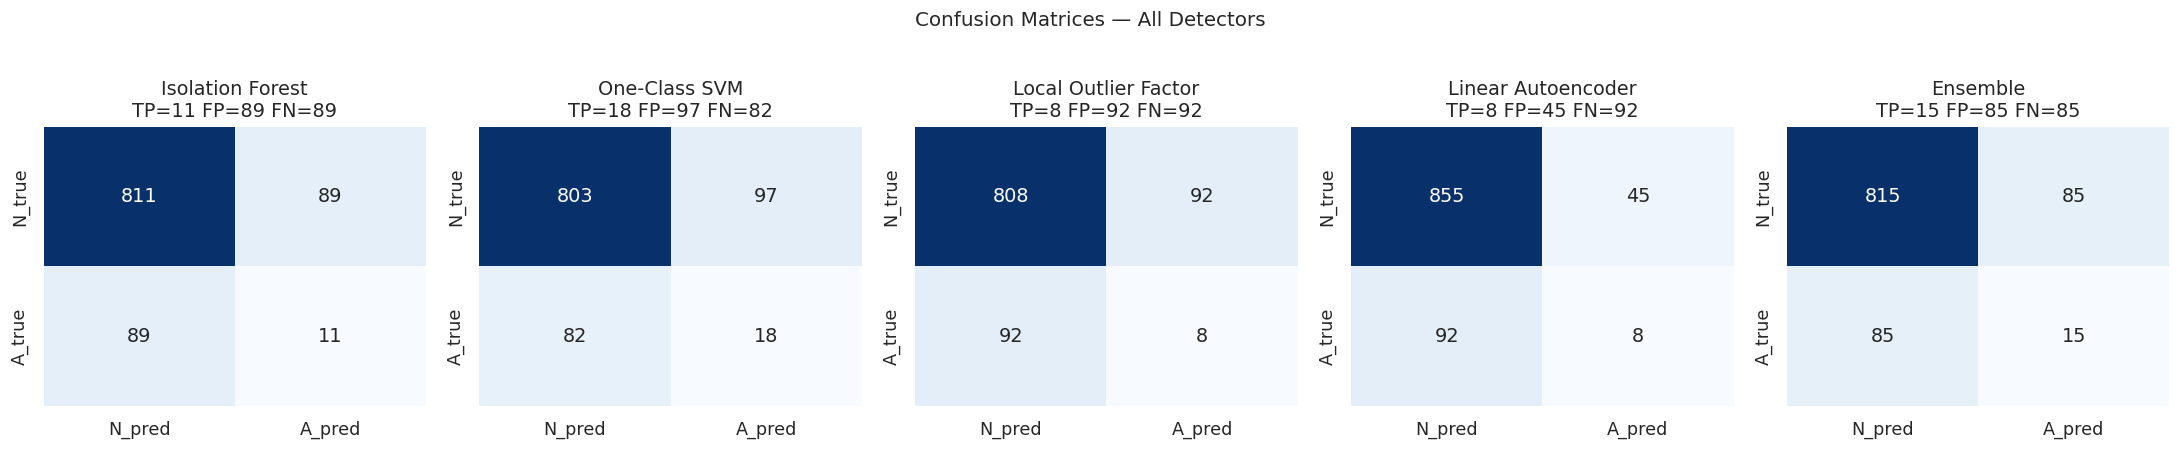

In [27]:
# ── Confusion matrices side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (title, pred, _) in zip(axes, configs):
    cm = confusion_matrix(y_sec, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['N_pred','A_pred'],
                yticklabels=['N_true','A_true'], cbar=False)
    tn,fp,fn,tp = cm.ravel()
    ax.set(title=f'{title}\nTP={tp} FP={fp} FN={fn}')
plt.suptitle('Confusion Matrices — All Detectors', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## B7 · Illustrating the Three Anomaly Types on Network Data

Let us construct concrete examples of all three anomaly types from the network dataset.


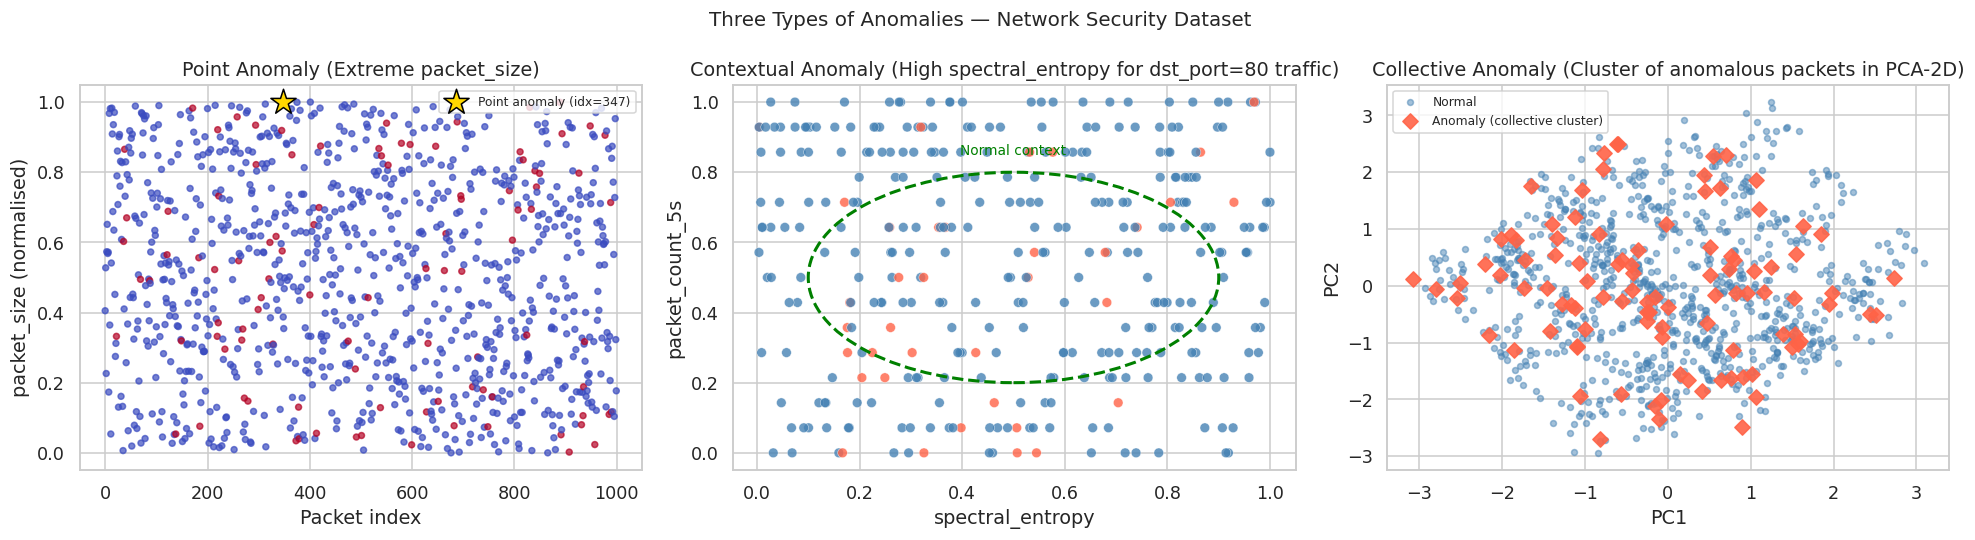

Point anomaly     - one individual data point is extreme (rare extreme value).
Contextual anomaly- normal-looking value, but anomalous given the context (port 80 high spectral entropy).
Collective anomaly- a group of packets that individually look normal but together form an attack pattern.


In [29]:
# ── Three Anomaly Types — illustrated on network data ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Point Anomaly: single packet with extreme packet_size ──────────────────
ax = axes[0]
ax.scatter(range(len(sec_raw)), sec_raw['packet_size'],
           c=y_sec, cmap='coolwarm', s=15, alpha=0.7)
extreme_idx = sec_raw['packet_size'].idxmax()
ax.scatter(extreme_idx, sec_raw.loc[extreme_idx,'packet_size'],
           marker='*', s=300, c='gold', edgecolors='black', zorder=5,
           label=f'Point anomaly (idx={extreme_idx})')
ax.set(title='Point Anomaly (Extreme packet_size)',
       xlabel='Packet index', ylabel='packet_size (normalised)')
ax.legend(fontsize=8)

# ── 2. Contextual Anomaly: high entropy packet count in a port-80 context ─────
ax = axes[1]
port80_mask = sec_raw['dst_port'] == 80
ax.scatter(sec_raw.loc[port80_mask, 'spectral_entropy'],
           sec_raw.loc[port80_mask, 'packet_count_5s'],
           c=['tomato' if v==1 else 'steelblue' for v in y_sec[port80_mask]],
           s=40, alpha=0.8, edgecolors='white', linewidths=0.3)
ax.set(title='Contextual Anomaly (High spectral_entropy for dst_port=80 traffic)',
       xlabel='spectral_entropy', ylabel='packet_count_5s')
# Add reference ellipse for "normal" region
from matplotlib.patches import Ellipse
ell = Ellipse(xy=(0.5, 0.5), width=0.8, height=0.6,
              angle=0, edgecolor='green', fc='none', lw=2, linestyle='--')
ax.add_patch(ell)
ax.text(0.5, 0.85, 'Normal context', color='green', ha='center', fontsize=9)

# ── 3. Collective Anomaly: cluster of anomalous points in PCA space ───────────
ax = axes[2]
ax.scatter(Z_sec_2d[y_sec==0, 0], Z_sec_2d[y_sec==0, 1],
           s=15, alpha=0.5, c='steelblue', label='Normal')
ax.scatter(Z_sec_2d[y_sec==1, 0], Z_sec_2d[y_sec==1, 1],
           s=50, alpha=0.9, c='tomato', marker='D', label='Anomaly (collective cluster)')
ax.set(title='Collective Anomaly (Cluster of anomalous packets in PCA-2D)',
       xlabel='PC1', ylabel='PC2')
ax.legend(fontsize=8)

plt.suptitle('Three Types of Anomalies — Network Security Dataset', fontsize=13)
plt.tight_layout(); plt.show()
print("Point anomaly     - one individual data point is extreme (rare extreme value).")
print("Contextual anomaly- normal-looking value, but anomalous given the context (port 80 high spectral entropy).")
print("Collective anomaly- a group of packets that individually look normal but together form an attack pattern.")

---
## 📋 Module Summary

### Part A — Dimensionality Reduction

| Method | Type | Preserves | Best for |
|---|---|---|---|
| PCA | Linear | Global variance | Pre-processing, noise removal, visualisation |
| t-SNE | Nonlinear | Local neighbourhoods | Cluster visualisation, exploration |
| UMAP | Nonlinear | Local + some global | Large datasets, production pipelines |

**Key rules:**
- Always **standardise** before any dimensionality reduction.
- Use the **scree plot** to choose the number of PCA components (elbow or 95 % EVR).
- Do **not** interpret inter-cluster distances in t-SNE plots.
- Run PCA before t-SNE when $d > 50$.
- Use PCA as a pre-processing step before clustering to improve K-Means quality.

---

### Part B — Anomaly Detection

| Method | Assumption | Speed | New-point prediction |
|---|---|---|---|
| Isolation Forest | Anomalies are easy to isolate | ⚡ Fast | ✅ Yes |
| One-Class SVM | Normal data enclosed in hypersphere | 🐢 Slow (large n) | ✅ Yes |
| LOF | Anomalies have low local density | 🐢 Slow (large n) | ❌ (novelty=False) |
| Autoencoder | Normal data can be reconstructed well | ⚡ Fast (GPU) | ✅ Yes |

**Key rules:**
- Set `contamination` as close to the true anomaly rate as domain knowledge allows.
- **Ensemble** multiple detectors to reduce false positives in production.
- Always validate with labelled hold-out data when possible.
- Choose the threshold based on the cost trade-off: high recall (catch all attacks) vs
  high precision (minimise alert fatigue).

---
*End of Module 6 — Dimensionality Reduction & Anomaly Detection*
